<a href="https://colab.research.google.com/github/mkRuby009/nmcn_course/blob/W0_foundations/LIFNeuron_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIF Neuron Part 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Constants for the neuron model
t_max = 150e-3   # second
dt = 1e-3        # second
tau = 20e-3      # second
el = -60e-3      # milivolt
vr = -70e-3      # milivolt
vth = -50e-3     # milivolt
r = 100e6        # ohm
i_mean = 25e-11  # ampere


$V(t)$ is the membrane potential,  
$\tau_m$ is the membrane time constant,  
$E_{L}$ is the leak potential,  
$R$ is the membrane resistance,  
$I(t)$ is the synaptic input current,  
$V_{th}$ is the firing threshold,  
and $V_{reset}$ is the reset voltage.  

We can also write $V_m$ for membrane potential, which is more convenient for plot labels.

The membrane equation describes the time evolution of membrane potential
in response to synaptic input and leaking of charge across the cell membrane. This is an ordinary differential equation (ODE), a concept we will learn more about in future days.

In [ ]:
print(t_max, dt, tau, el, vr, vth, r, i_mean)

0.15 0.001 0.02 -0.06 -0.07 -0.05 100000000.0 2.5e-10


In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
x = 3.14159265e-1
print(f'{x:.3f}')

0.314


In [ ]:
print(f'{x:.4e}')

3.1416e-01


In [ ]:
for step in range(10):
  print(step)

0
1
2
3
4
5
6
7
8
9


In [ ]:
for step in range(10):
  #compute value of t
  t = step*dt

  #compute value of i at this step
  i_t = i_mean * (1 + np.sin ((2* np.pi/0.01)*t) )

  print(i_t)

2.5e-10
3.969463130731183e-10
4.877641290737885e-10
4.877641290737885e-10
3.9694631307311837e-10
2.5000000000000007e-10
1.0305368692688166e-10
1.2235870926211617e-11
1.223587092621159e-11
1.0305368692688186e-10


In [ ]:
step_end = 10
for step in range(step_end):

  #compute value of t
  t = step*dt

  #compute value of i at this step
  i_t = i_mean * (1 + np.sin ((2* np.pi/0.01)*t) )

  print(f't={t:.3f}, I(t)={i_t:.4e}')

t=0.000, I(t)=2.5000e-10
t=0.001, I(t)=3.9695e-10
t=0.002, I(t)=4.8776e-10
t=0.003, I(t)=4.8776e-10
t=0.004, I(t)=3.9695e-10
t=0.005, I(t)=2.5000e-10
t=0.006, I(t)=1.0305e-10
t=0.007, I(t)=1.2236e-11
t=0.008, I(t)=1.2236e-11
t=0.009, I(t)=1.0305e-10


In [ ]:
for step in [0,1,2]:
  print(step)

0
1
2


In [ ]:
for step in range(3):
  print(step)

0
1
2


In [ ]:
start = 0
end = 3
stepsize = 1
for step in range(0,10,2):
  print(step)


0
2
4
6
8


## Coding Exercise 4: Simulating membrane potential

In [ ]:
step_end = 10
#V(0) = el
v= el

for step in range(step_end):

  t = step * dt
  #compute value of i at this step
  i = i_mean * (1 + np.sin ((2* np.pi/0.01)*t) )

  v = v + (dt/tau)* (el-v + r*i)

  print(f'{t:.3f} {v:.4e}')

2.5e-10 -0.05875
3.969463130731183e-10 -0.056827768434634406
4.877641290737885e-10 -0.05454755936753374
4.877641290737885e-10 -0.05238136075378811
3.9694631307311837e-10 -0.05077756115073311
2.5000000000000007e-10 -0.049988683093196457
1.0305368692688166e-10 -0.04997398050390223
1.2235870926211617e-11 -0.05041410212407606
1.223587092621159e-11 -0.0508322176632412
1.0305368692688186e-10 -0.050775338345444725


## Coding Exercise 5: Plotting current

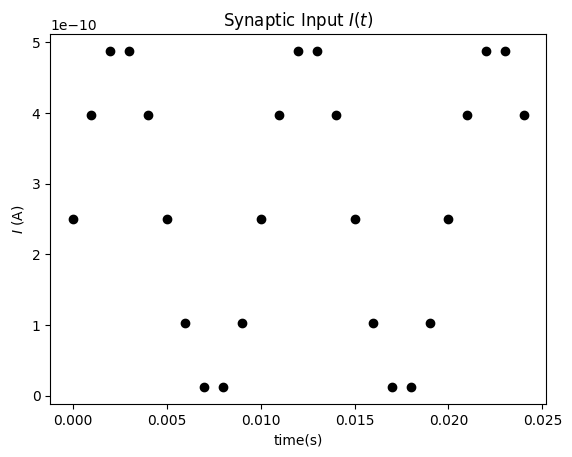

In [ ]:
# Plotting the values of I(t) between t=0 and t=0.024

step_end = 25


#initialize the plot
plt.figure()
plt.title("Synaptic Input $I(t)$")
plt.xlabel("time(s)")
plt.ylabel("$I$ (A)")

#loop for step_end number of steps
for step in range(step_end):
  #compute value of t
  t = step * dt
  #compute value of i at this step
  i = i_mean * (1 + np.sin ((2* np.pi/0.01)*t) )

  #(use 'ko' to get small black dots (short for color='k' and marker = 'o'))
  plt.plot(t, i, 'ko')

plt.show()

## Coding Exercise 6: Plotting membrane potential

In [ ]:
# Plotting the value of V(t) between t=0 and t=tmax. We can compute the number of steps required to get to t=tmax given delta t as int(t_max/dt)

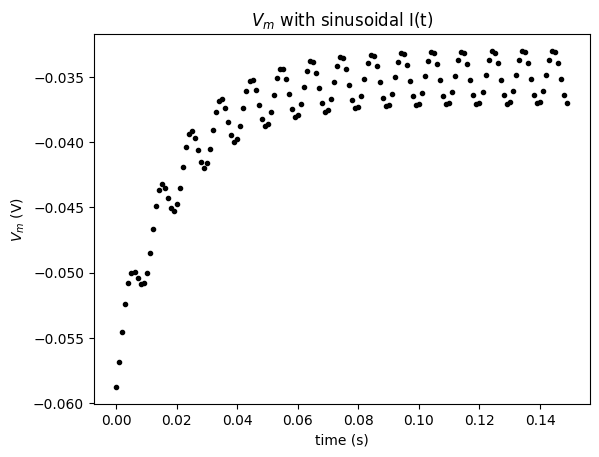

In [ ]:
step_end = int(t_max/dt)

v=el
plt.figure()
plt.title('$V_m$ with sinusoidal I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

for step in range(step_end):

  t = step*dt

  i = i_mean * (1 + np.sin ((2* np.pi/0.01)*t) )

  v = v + (dt/tau)* (el-v + r*i)

  #(use 'ko' to get small black dots (short for color='k' and marker = 'o'))
  plt.plot(t, v, 'k.')

plt.show()

## Coding Exercise 7: Adding randomness
Plotting the values of V(t) between t=0 and t=tmax -delta t with random input I(t)


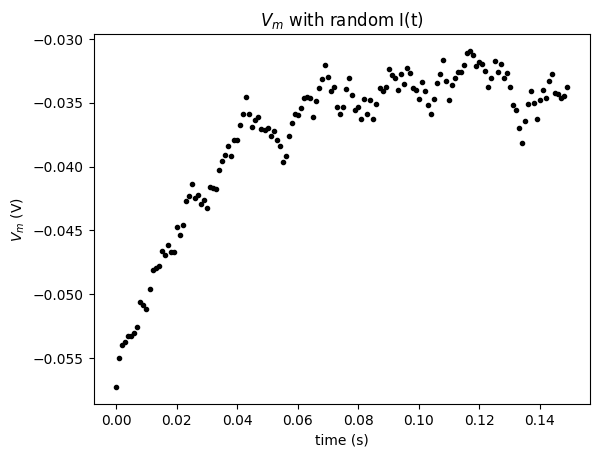

In [ ]:
np.random.seed(2020)

step_end = int(t_max/dt)
v=el

plt.figure()
plt.title('$V_m$ with random I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

for step in range(step_end):

  t = step*dt

  random_num = 2*np.random.random() - 1

  i = i_mean * (1 + 0.1 * (t_max/dt)**(0.5) * random_num )

  v = v + (dt/tau)* (el - v + r*i)

  #(use 'ko' to get small black dots (short for color='k' and marker = 'o'))
  plt.plot(t, v, 'k.')
  #print(f'i={i:0.4e}, v={v:.3f}')

plt.show()

In [ ]:
mylist = [1,2,3]
mylist.append('b')
print(mylist)

[1, 2, 3, 'b']


In [ ]:
mylist.extend([7])
print(mylist)

[1, 2, 3, 'b', 7]


In [ ]:
newlist = ["howdy"]+ mylist
print(newlist)

['howdy', 1, 2, 3, 'b', 7, 8]


In [ ]:
print(mylist[-1])

8


In [ ]:
print(mylist[-2])

7


In [ ]:
mylist = ['pyramidal','inhibitory','glial']

for idx, item in enumerate(mylist):
  print(idx, item)

0 pyramidal
1 inhibitory
2 glial


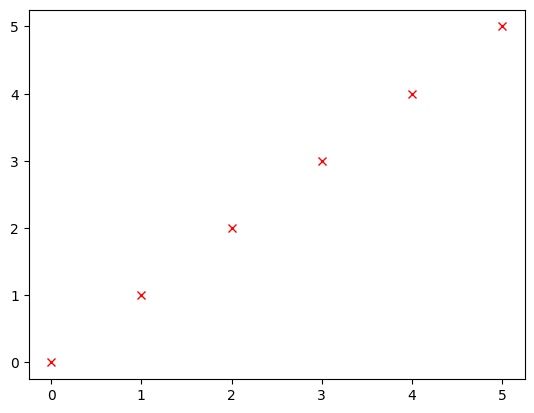

In [ ]:
x = [0,1,2,3,4,5]
plt.plot(x, x, 'rx')

## Coding Exercise 8: Storing simulations in lists

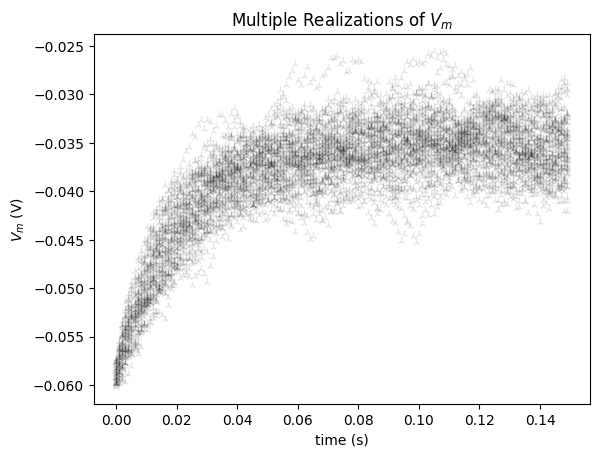

In [ ]:
np.random.seed(2020)

step_end = int(t_max/dt)
n = 50

#initialize the list v_n with 50 values with leak potential
v_n=[el]*n

plt.figure()
plt.title('Multiple Realizations of $V_m$')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

for step in range(step_end):

  t = step*dt

  for j in range(0, n):
    random_num = 2*np.random.random() - 1

    i = i_mean * (1 + 0.1 * (t_max/dt)**(0.5) * random_num )

    v_n[j] = v_n[j] + (dt/tau)* (el - v_n[j] + r*i)

  #(use 'ko' to get small black dots (short for color='k' and marker = 'o'))
  plt.plot([t]*n, v_n, 'k2', alpha=0.1)

plt.show()

## Coding Exercise 9: Plotting sample mean

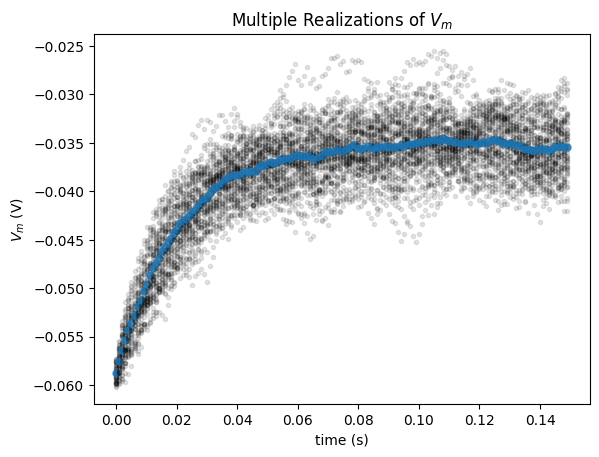

In [ ]:
np.random.seed(2020)

step_end = int(t_max/dt)
n = 50

#initialize the list v_n with 50 values with leak potential
v_n=[el]*n

plt.figure()
plt.title('Multiple Realizations of $V_m$')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

for step in range(step_end):

  t = step*dt

  for j in range(0, n):
    random_num = 2*np.random.random() - 1

    i = i_mean * (1 + 0.1 * (t_max/dt)**(0.5) * random_num )

    v_n[j] = v_n[j] + (dt/tau)* (el - v_n[j] + r*i)

  # Computing the sample mean by summing list of v_n using sum, and divinding by n
  v_mean = sum(v_n)/ n

  # plot simulations
  plt.plot(n*[t], v_n, 'k.', alpha=0.1)

  #plot sample mean using alpha=0.8 and 'C0.' for blue
  plt.plot(t, v_mean, 'C0.', alpha=0.8, markersize=10)

plt.show()

In [ ]:
n=5
t= 2
print(n*[t])

[2, 2, 2, 2, 2]


## Coding Exercise 10: Plotting sample standard deviation

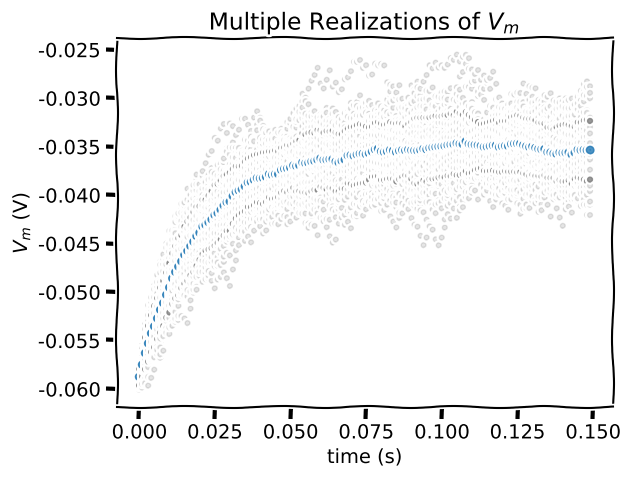

In [ ]:
np.random.seed(2020)

step_end = int(t_max/dt)
n = 50

#initialize the list v_n with 50 values with leak potential
v_n=[el]*n

with plt.xkcd():
  plt.figure()
  plt.title('Multiple Realizations of $V_m$')
  plt.xlabel('time (s)')
  plt.ylabel('$V_m$ (V)')

  for step in range(step_end):

    t = step*dt

    for j in range(0, n):
      random_num = 2*np.random.random() - 1

      i = i_mean * (1 + 0.1 * (t_max/dt)**(0.5) * random_num )

      v_n[j] = v_n[j] + (dt/tau)* (el - v_n[j] + r*i)

    # Computing the sample mean by summing list of v_n using sum, and divinding by n
    v_mean = sum(v_n)/ n

    #initialize a list 'v_var_n' with the contribution of each V_n(t) to
    # Var(t) with a list comprehension over values of v_n
    v_var_n = [(v - v_mean)**2 for v in v_n]

    #compute sample variance V_var by summing the values of v_var_n and diving by n-1
    v_var = sum(v_var_n)/(n-1)

    #standard deviation
    v_std = np.sqrt(v_var)
    # -----------------plots --------------------
    # plot simulations
    plt.plot(n*[t], v_n, 'k.', alpha=0.1)

    #plot sample mean using alpha=0.8 and 'C0.' for blue
    plt.plot(t, v_mean, 'C0.', alpha=0.8, markersize=10)

    #plot mean + standard deviation with alpha=0.8 and argument 'C7.'
    plt.plot(t, v_mean + v_std, 'C7.', alpha=0.8)

    #plot mean - standard deviation with alpha=0.8 and argument 'C7.'
    plt.plot(t, v_mean - v_std, 'C7.', alpha=0.8)

  plt.show()

In [ ]:
arr = np.array([[1,2,3],
                [4,5,6]])
print(arr.shape)

(2, 3)


In [ ]:
print(arr*3)

[[ 3  6  9]
 [12 15 18]]


In [ ]:
np.sum(arr, axis=0)

array([5, 7, 9])

In [ ]:
np.sum(arr, axis=1)

array([ 6, 15])

In [ ]:
print(np.sum(arr))

21


In [ ]:
a = np.array([1,2,3])
b = np.array([[1,2,3]])

print(a.shape)
print(b.shape)

(3,)
(1, 3)


## Coding Exercise 11: Rewriting with NumPy

In [ ]:
print(np.linspace(0, 10, retstep=True))

(array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ]), np.float64(0.20408163265306123))


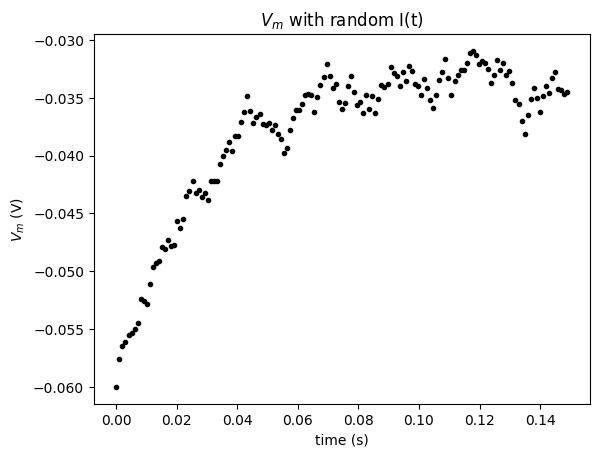

In [ ]:
np.random.seed(2020)

#initialize step_end, t_range, v
step_end = int(t_max/dt) -1
t_range = np.linspace(0, t_max, num=step_end, endpoint=False)
v = el * np.ones(step_end)

# Simulate current over time (Here, i is resultant np.array??)
i = i_mean * (1 + 0.1 * (t_max/dt)** (0.5) * (2* np.random.random(step_end)-1 ))

for step in range(1, step_end):
  v[step] = v[step - 1] + (dt / tau) * (el - v[step-1] + r * i[step])


plt.figure()
plt.title('$V_m$ with random I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

# -----------------plots --------------------
# plot for membrane potential
plt.plot(t_range, v, 'k.')

plt.show()

## Coding Exercise 12: Using enumerate & indexing

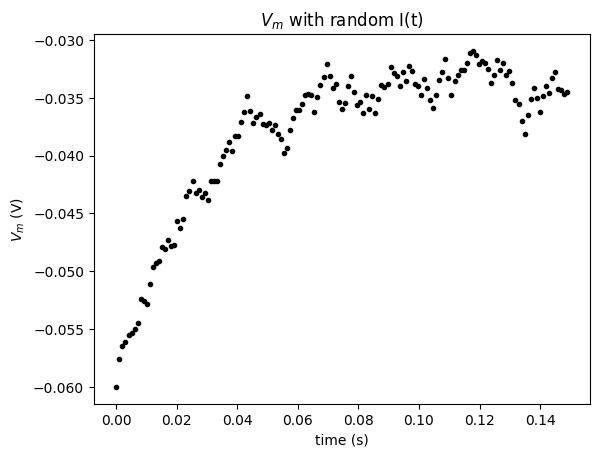

In [ ]:
np.random.seed(2020)

#initialize step_end, t_range, v
step_end = int(t_max/dt) -1
t_range = np.linspace(0, t_max, num=step_end, endpoint=False)
v = el * np.ones(step_end)

# Simulate current over time (Here, i is resultant np.array??)
i = i_mean * (1 + 0.1 * (t_max/dt)** (0.5) * (2* np.random.random(step_end)-1 ))

for step, i_step in enumerate(i):
  if step ==0:
    continue

  #Compute v as a function of i using i_step
  v[step] = v[step - 1] + (dt / tau) * (el - v[step-1] + r * i_step)

#plot figure
plt.figure()
plt.title('$V_m$ with random I(t)')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')

# -----------------plots --------------------
# plot for membrane potential
plt.plot(t_range, v, 'k.')

plt.show()

## Coding Exercise 13: Using 2D arrays to plot multiple realizations N=50

In [ ]:
var = np.random.random(1)
print(type(var))
print(var)

<class 'numpy.ndarray'>
[0.65975484]


In [ ]:
step_end = int(t_max/ dt)
n = 50
np_arr = np.random.random([n,step_end])
print(np_arr.shape)

(50, 150)


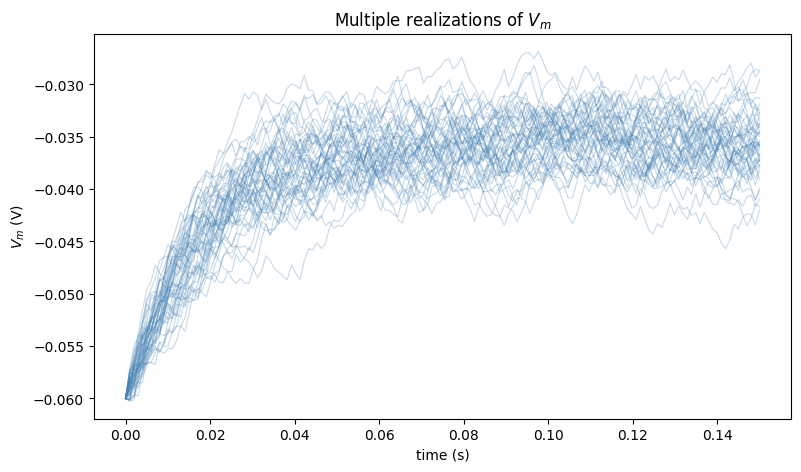

In [ ]:
np.random.seed(2020)

#initialize step_end, n , t_range, v and i
step_end = int(t_max/ dt)
n = 50
t_range = np.linspace(0, t_max, num=step_end)
v_n = el * np.ones([n, step_end])

i = i_mean * (1 + 0.1 * (t_max/ dt)** (0.5) * (2 * np.random.random([n,step_end]) - 1 ))

for step in range(1, step_end):
  #Compute v as a function of i using i_step
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step-1] + r * i[:, step])


#plot figure
# -----------------plots --------------------
# plot for membrane potential
plt.figure(figsize=(9, 5))
plt.title('Multiple realizations of $V_m$')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')
plt.plot(t_range, v_n.T, color='steelblue', alpha=0.3, linewidth=0.8)

plt.show()

## Coding Exercise 14: Plotting sample mean and standard deviation

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_450/1317979522.py:30: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t_range, v_mean-v_std, 'r', alpha=0.8, label='mean $\pm$ std')


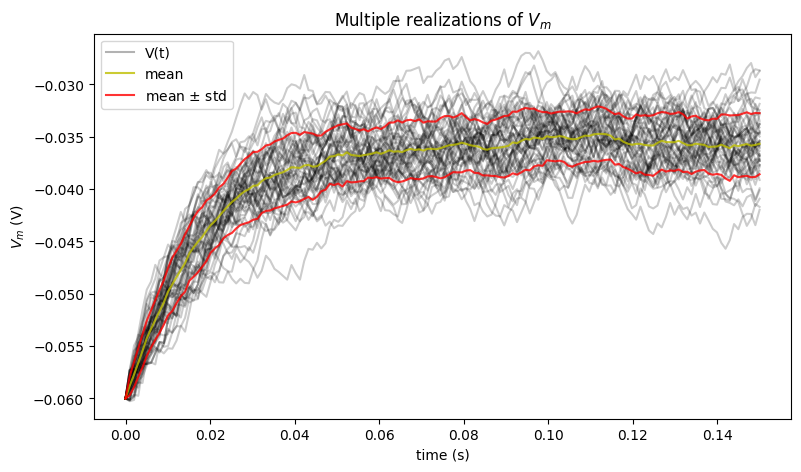

In [ ]:
np.random.seed(2020)

#initialize step_end, n , t_range, v and i
step_end = int(t_max/ dt)
n = 50
t_range = np.linspace(0, t_max, num=step_end)
v_n = el * np.ones([n, step_end])
i = i_mean * (1 + 0.1 * (t_max/ dt)** (0.5) * (2 * np.random.random([n,step_end]) - 1 ))

for step in range(1, step_end):
  #Compute v as a function of i using i_step
  v_n[:, step] = v_n[:, step - 1] + (dt / tau) * (el - v_n[:, step-1] + r * i[:, step])

v_mean = np.mean(v_n, axis=0)

v_std = np.std(v_n, axis=0)

#plot figure
# -----------------plots --------------------
# plot for membrane potential
plt.figure(figsize=(9, 5))
plt.title('Multiple realizations of $V_m$')
plt.xlabel('time (s)')
plt.ylabel('$V_m$ (V)')
plt.plot(t_range, v_n.T, 'k', alpha=0.2)

plt.plot(t_range, v_n[-1], 'k', alpha=0.3, label='V(t)')
plt.plot(t_range, v_mean, 'y', alpha=0.8, label='mean')
plt.plot(t_range, v_mean+v_std, 'r', alpha=0.8)
plt.plot(t_range, v_mean-v_std, 'r', alpha=0.8, label='mean $\pm$ std')

plt.legend()
plt.show()